In [1]:
import matplotlib.pyplot as plt

import scanpy as sc
import numpy as np
import pandas as pd

In [2]:
%gui qt

In [3]:
import matplotlib as mpl

# ---- Global style: use Arial everywhere ----
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],  # falls back if Arial missing
    "pdf.fonttype": 42,  # embed TrueType (keeps Arial in PDFs)
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "font.size": 12,
})

# **Visualization and evaluation functions**

In [4]:
import numpy as np

try:
    import scipy.sparse as sp
except ImportError:
    sp = None

def weighted_kabsch_with_transport(A, B, P, return_aligned=True):
    """
    Find R (rotation) and t (translation) that best align A -> B
    by minimizing sum_{i,j} P[i,j] * || R @ A[i] + t - B[j] ||^2
    subject to R being a proper rotation (orthonormal, det=+1).

    Parameters
    ----------
    A : (n, d) array
        Source points (d = 2 or 3).
    B : (m, d) array
        Target points.
    P : (n, m) array-like
        Transport/weight matrix (nonnegative). Can be dense numpy or scipy.sparse.
    return_aligned : bool
        If True, also return A_aligned = (A @ R^T) + t for convenience.

    Returns
    -------
    R : (d, d) ndarray
        Rotation matrix mapping A to B.
    t : (d,) ndarray
        Translation vector.
    A_aligned : (n, d) ndarray  [only if return_aligned=True]
        Transformed A.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    n, d = A.shape
    m, dB = B.shape
    if d != dB:
        raise ValueError(f"A and B must have same dimensionality, got {d} vs {dB}.")
    if sp is not None and sp.issparse(P):
        P_csr = P.tocsr()
        total_w = float(P_csr.sum())
        if total_w <= 0:
            raise ValueError("All weights in P are zero.")
        # row/col sums
        w_rows = np.array(P_csr.sum(axis=1)).ravel()   # (n,)
        w_cols = np.array(P_csr.sum(axis=0)).ravel()   # (m,)
        # weighted centroids
        mu_A = (A.T @ w_rows) / total_w               # (d,)
        mu_B = (B.T @ w_cols) / total_w               # (d,)
        A_c = A - mu_A
        B_c = B - mu_B
        # covariance H = A_c^T @ P @ B_c  (d x d)
        # do it as (A_c^T @ (P @ B_c)) to keep it sparse-friendly
        PBc = P_csr @ B_c                              # (n, d)
        H = A_c.T @ PBc                                # (d, d)
    else:
        P = np.asarray(P, dtype=float)
        if P.shape != (n, m):
            raise ValueError(f"P must be shape {(n,m)}, got {P.shape}.")
        total_w = P.sum()
        if total_w <= 0:
            raise ValueError("All weights in P are zero.")
        w_rows = P.sum(axis=1)                         # (n,)
        w_cols = P.sum(axis=0)                         # (m,)
        mu_A = (A.T @ w_rows) / total_w                # (d,)
        mu_B = (B.T @ w_cols) / total_w                # (d,)
        A_c = A - mu_A
        B_c = B - mu_B
        H = A_c.T @ (P @ B_c)                          # (d, d)

    # SVD of covariance
    U, S, Vt = np.linalg.svd(H, full_matrices=False)
    # Proper rotation: R = V * U^T (a.k.a. Kabsch)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:  # avoid reflection
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    # translation: mu_B = R @ mu_A + t  -> t = mu_B - R @ mu_A
    t = mu_B - R @ mu_A

    if return_aligned:
        # Apply: X' = R @ X + t  (row-wise: X @ R^T + t)
        A_aligned = (A @ R.T) + t
        return R, t, A_aligned
    else:
        return R, t

import json

def get_camera_state(fig=None):
    fig = fig or mlab.gcf()
    cam = fig.scene.camera
    state = {
        "position":         tuple(cam.position),
        "focal_point":      tuple(cam.focal_point),
        "view_up":          tuple(cam.view_up),
        "clipping_range":   tuple(cam.clipping_range),
        "parallel_projection": bool(cam.parallel_projection),
        "parallel_scale":   float(cam.parallel_scale),  # used if parallel_projection=True
        "view_angle":       float(cam.view_angle),      # used if parallel_projection=False
    }
    return state

def set_camera_state(state, fig=None):
    fig = fig or mlab.gcf()
    cam = fig.scene.camera
    cam.position         = state["position"]
    cam.focal_point      = state["focal_point"]
    cam.view_up          = state["view_up"]
    cam.clipping_range   = state["clipping_range"]
    cam.parallel_projection = state["parallel_projection"]
    cam.parallel_scale   = state["parallel_scale"]
    cam.view_angle       = state["view_angle"]
    mlab.draw()  # or: fig.scene.render()

def add_headlight(intensity=1.0, clear_existing=False):
    fig = mlab.gcf()
    ren = fig.scene.renderer

    if clear_existing:
        # take full control of lights (optional)
        ren.automatic_light_creation = False
        for L in list(ren.lights):
            ren.remove_light(L)

    light = tvtk.Light()

    # Set light type to a headlight (follows the camera), with fallbacks
    if hasattr(light, "set_light_type_to_headlight"):
        light.set_light_type_to_headlight()
    else:
        # enum name is case-sensitive in tvtk
        try:
            light.light_type = 'Headlight'
        except Exception:
            try:
                # camera light also follows the camera
                if hasattr(light, "set_light_type_to_camera_light"):
                    light.set_light_type_to_camera_light()
                else:
                    light.light_type = 'camera_light'
            except Exception:
                pass  # last resort: keep whatever default it has

    light.intensity = float(intensity)

    # Turn it on (different APIs across VTK/TVTK versions)
    if hasattr(light, "switch_on"):
        light.switch_on()
    else:
        try:
            light.switch = True
        except Exception:
            pass

    ren.add_light(light)
    fig.scene.render()

def save_highres(filename, size=(4000, 3000), pad=1.08, parallel=True, hide_orientation=True):
    """Pad the view a bit so nothing gets clipped, then save at high resolution."""
    fig = mlab.gcf()
    scene = fig.scene

    # (optional) hide the corner XYZ gizmo if it gets cropped
    if hide_orientation:
        for c in list(fig.children):
            if c.__class__.__name__ == 'OrientationAxes':
                try:
                    c.visible = False
                except Exception:
                    pass

    scene.render()
    scene.reset_zoom()                      # fit all visible actors
    cam = scene.camera

    if parallel:
        cam.parallel_projection = True      # nice for figures (no foreshortening)
        cam.parallel_scale *= pad           # zoom out a bit to add margin
    else:
        cam.zoom(1.0 / pad)                 # perspective: zoom out slightly

    # Update clipping planes just in case
    scene.render()

    # Save at explicit resolution (pick one: size OR magnification)
    mlab.savefig(filename, size=size)       # e.g., (5000, 4000)

In [5]:
import numpy as np
from collections import defaultdict
from itertools import product
from mayavi import mlab
from tvtk.api import tvtk
from mayavi.sources.vtk_data_source import VTKDataSource

def plot_st_triplet_mayavi_fast(
    A_xy, B_xy, C_xy,
    W12, W23,
    labels_A, labels_B, labels_C,
    *,
    z_levels=(0.0, 1.0, 2.0),
    type_colors=None,        # dict {"A":(r,g,b), "B":..., "C":...}
    pair_colors=None,        # dict {("A","B"):(r,g,b), ...}
    use_tubes=True,          # True=tubes (pretty); False=lines (fastest)
    tube_radius_intra=0.018, # same-type edges (A→A etc.)
    tube_radius_inter=0.012, # cross-type edges (A→B etc.)
    tube_sides=8,
    line_width=1.5,          # used if use_tubes=False
    point_scale=0.65,
    show_planes=False,
    plane_alpha=0.08,
    bg=(1,1,1)
):
    """
    A_xy, B_xy, C_xy: (Ni,2) arrays of XY coordinates per slice
    W12: (N1,N2) binary links A->B;  W23: (N2,N3) binary links B->C
    labels_*: length-Ni arrays of type strings (e.g., "A","B","C")
    """
    # --- inputs & checks
    A_xy = np.asarray(A_xy, float); B_xy = np.asarray(B_xy, float); C_xy = np.asarray(C_xy, float)
    W12 = np.asarray(W12); W23 = np.asarray(W23)
    labels_A = np.asarray(labels_A); labels_B = np.asarray(labels_B); labels_C = np.asarray(labels_C)
    n1, n2, n3 = len(A_xy), len(B_xy), len(C_xy)
    assert W12.shape == (n1, n2), f"W12 must be ({n1},{n2}), got {W12.shape}"
    assert W23.shape == (n2, n3), f"W23 must be ({n2},{n3}), got {W23.shape}"
    assert len(labels_A)==n1 and len(labels_B)==n2 and len(labels_C)==n3
    zA, zB, zC = z_levels

    # --- colors
    all_types = tuple(sorted(set(labels_A) | set(labels_B) | set(labels_C)))
    if type_colors is None:
        base = [(0.0,0.447,0.698),(0.800, 0.200, 0.067),(0.000, 0.620, 0.451)]
        type_colors = {t: base[i % len(base)] for i,t in enumerate(all_types)}
    if pair_colors is None:
        # same-type uses node color; cross-type uses contrasting palette
        palette = [
            (0.10,0.63,0.79),(0.85,0.37,0.01),(0.55,0.34,0.29),
            (0.89,0.47,0.76),(0.40,0.76,0.65),(0.80,0.68,0.22),
        ]
        pair_colors = {}
        idx = 0
        for s,t in product(all_types, repeat=2):
            pair_colors[(s,t)] = type_colors[s] if s==t else palette[idx % len(palette)]
            idx += 1

    # --- extents for optional planes & view
    all_xy = np.vstack([A_xy, B_xy, C_xy])
    xmin,ymin = all_xy.min(axis=0); xmax,ymax = all_xy.max(axis=0)
    pad_x = 0.05 * (xmax - xmin if xmax>xmin else 1.0)
    pad_y = 0.05 * (ymax - ymin if ymax>ymin else 1.0)
    xmin,xmax = xmin-pad_x, xmax+pad_x; ymin,ymax = ymin-pad_y, ymax+pad_y

    mlab.figure(size=(1000,820), bgcolor=bg)

    # --- draw points per slice, grouped by type (<= 3 actors per slice)
    def draw_slice(xy, z, labels, name):
        groups = defaultdict(list)
        for i,t in enumerate(labels): groups[t].append(i)
        for t,idxs in groups.items():
            idxs = np.asarray(idxs, int)
            mlab.points3d(
                xy[idxs,0], xy[idxs,1], np.full(len(idxs), z),
                scale_factor=point_scale, color=type_colors[t],
                resolution=18, opacity=1.0, name=f"{name}_{t}"
            )
        if show_planes:
            px,py = np.meshgrid(np.linspace(xmin,xmax,2), np.linspace(ymin,ymax,2))
            pz = np.full_like(px, z, float)
            mlab.mesh(px,py,pz, color=(0.96,0.96,0.96), opacity=plane_alpha)

    draw_slice(A_xy, zA, labels_A, "A")
    draw_slice(B_xy, zB, labels_B, "B")
    draw_slice(C_xy, zC, labels_C, "C")

    # --- helper: add a batch of E 2-point lines as ONE actor
    def add_edge_batch(P0, P1, color, intra: bool):
        if len(P0)==0: return
        E = len(P0)
        pts = np.empty((2*E, 3), dtype=float)
        pts[0::2] = P0; pts[1::2] = P1
        # connectivity: [2,0,1, 2,2,3, 2,4,5, ...]
        conn = np.empty((E,3), dtype=np.int64)
        conn[:,0] = 2
        conn[:,1] = 2*np.arange(E, dtype=np.int64)
        conn[:,2] = conn[:,1] + 1
        poly = tvtk.PolyData(points=pts)
        cells = tvtk.CellArray(); cells.set_cells(E, conn.ravel())
        poly.lines = cells

        src = VTKDataSource(data=poly); mlab.pipeline.add_dataset(src)
        if use_tubes:
            r = tube_radius_intra if intra else tube_radius_inter
            tube = mlab.pipeline.tube(src, tube_radius=r, tube_sides=tube_sides)
            mlab.pipeline.surface(tube, color=color)
        else:
            surf = mlab.pipeline.surface(src, color=color)
            surf.actor.property.line_width = float(line_width)

    # --- build & batch edges by (type_from, type_to)
    def batch_edges(xy0, z0, lab0, xy1, z1, lab1, W):
        I,J = np.where(W > 0)
        if len(I)==0: return
        src_t = lab0[I]; dst_t = lab1[J]
        for s,t in product(all_types, repeat=2):
            mask = (src_t==s) & (dst_t==t)
            if not np.any(mask): continue
            i_sel = I[mask]; j_sel = J[mask]
            P0 = np.column_stack((xy0[i_sel,0], xy0[i_sel,1], np.full(len(i_sel), z0)))
            P1 = np.column_stack((xy1[j_sel,0], xy1[j_sel,1], np.full(len(j_sel), z1)))
            add_edge_batch(P0, P1, pair_colors[(s,t)], intra=(s==t))

    batch_edges(A_xy, zA, labels_A, B_xy, zB, labels_B, W12)
    batch_edges(B_xy, zB, labels_B, C_xy, zC, labels_C, W23)

    mlab.orientation_axes()
    mlab.view(azimuth=45, elevation=70, distance='auto',
              focalpoint=((xmin+xmax)/2, (ymin+ymax)/2, (zA+zC)/2))
    return mlab.gcf()

objc[17142]: Class RunLoopModeTracker is implemented in both /opt/anaconda3/envs/mayavi_env/lib/libQt5Core.5.15.15.dylib (0x3011d9370) and /opt/anaconda3/envs/mayavi_env/lib/libQt6Core.6.9.3.dylib (0x32b8455d0). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[17142]: Class QT_ROOT_LEVEL_POOL__THESE_OBJECTS_WILL_BE_RELEASED_WHEN_QAPP_GOES_OUT_OF_SCOPE is implemented in both /opt/anaconda3/envs/mayavi_env/lib/libQt5Core.5.15.15.dylib (0x3011d92f8) and /opt/anaconda3/envs/mayavi_env/lib/libQt6Core.6.9.3.dylib (0x32b845698). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[17142]: Class KeyValueObserver is implemented in both /opt/anaconda3/envs/mayavi_env/lib/libQt5Core.5.15.15.dylib (0x3011d9320) and /opt/anaconda3/envs/mayavi_env/lib/libQt6Core.6.9.3.dylib (0x32b8456c0). This may cause spurious casting failures and mysterious crashes. One of the 

In [6]:
def P_to_T(P, thresh=1e-5):
    T = np.zeros_like(P)
    for i in range(P.shape[0]):
        if P[i,:].max() > thresh:
            T[i,np.argmax(P[i,:])] = 1
    return T

# **Load data**

In [7]:
data_path = './data/04.mouse.midbrain.three.time.point.ST.exp.h5ad'
adata_all = sc.read_h5ad(data_path)

adata_1=adata_all[adata_all.obs['Time point']=='E12.5']
adata_2=adata_all[adata_all.obs['Time point']=='E14.5']
adata_3=adata_all[adata_all.obs['Time point']=='E16.5']
adata_all.uns['annotation_colors']=['#9A154C', '#F3754E', '#5B58A7']

In [8]:
X1 = adata_1.obsm['spatial']
X2 = adata_2.obsm['spatial']
X3 = adata_3.obsm['spatial']

(np.float64(-579.9951365963326),
 np.float64(16513.897868522985),
 np.float64(-10149.947464758201),
 np.float64(-6851.103240077771))

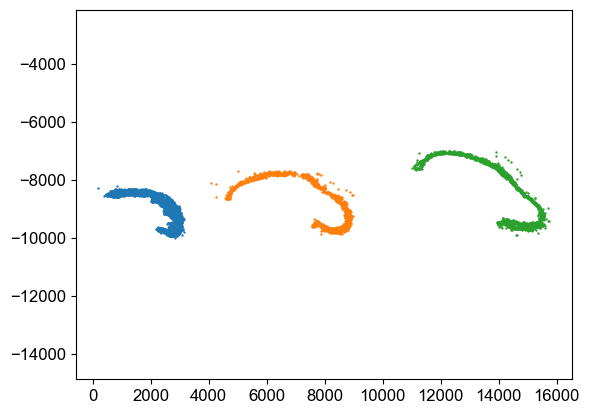

In [9]:
plt.scatter(X1[:,0], X1[:,1], s=0.5)
plt.scatter(X2[:,0], X2[:,1], s=0.5)
plt.scatter(X3[:,0], X3[:,1], s=0.5)
plt.axis('equal')

In [10]:
adata_1

View of AnnData object with n_obs × n_vars = 2237 × 24045
    obs: 'annotation', 'Time point', 'x', 'y', 'batch', 'cell_id'
    obsm: 'spatial'

In [11]:
adata_2

View of AnnData object with n_obs × n_vars = 953 × 24045
    obs: 'annotation', 'Time point', 'x', 'y', 'batch', 'cell_id'
    obsm: 'spatial'

In [12]:
adata_3

View of AnnData object with n_obs × n_vars = 1338 × 24045
    obs: 'annotation', 'Time point', 'x', 'y', 'batch', 'cell_id'
    obsm: 'spatial'

In [13]:
P12_rfp = np.loadtxt("./E125_E145/align_data/full_matching_E125E145_6.5_0.95_7_10000_0.8301296379079124_relative.csv", delimiter=",")
P23_rfp = np.loadtxt("./E145_E165/align_data/full_matching_E145E165_6.5_0.95_12_10000_0.8656873032528857_relative.csv", delimiter=",")

In [14]:
T_AB_rfp = P_to_T(P12_rfp)
T_BC_rfp = P_to_T(P23_rfp)
_,_,X1_match = weighted_kabsch_with_transport(X1, X2, P12_rfp, return_aligned=True)
_,_,X3_match = weighted_kabsch_with_transport(X3, X2, P23_rfp.T, return_aligned=True)

label_A = np.array( adata_1.obs['annotation'] )
label_B = np.array( adata_2.obs['annotation'] )
label_C = np.array( adata_3.obs['annotation'] )

In [15]:
labels_order=['RGC','GlioB','NeuB']
base = [(0.0,0.447,0.698),(0.800, 0.200, 0.067),(0.000, 0.620, 0.451)]
type_colors = dict(zip(labels_order, base))
pair_colors = {(s, t): type_colors[s] for s in labels_order for t in labels_order}

fig = plot_st_triplet_mayavi_fast(
    X1_match, X2, X3_match, T_AB_rfp, T_BC_rfp, label_A, label_B, label_C,
    use_tubes=True,        # pretty; set False for fastest lines
    show_planes=False,     # switch True if you want faint background planes
    tube_radius_intra=0.5,
    tube_radius_inter=0.5,
    point_scale=40,
    type_colors=type_colors,
    pair_colors=pair_colors,
    z_levels=(0.0, 3500, 8000)
)

In [16]:
mlab.savefig("figures/three_time_point_alignment.png", figure=fig, size=(2400, 1800))